#### validation dataset generation   

In [1]:
import torch
import numpy as np 
from glob import glob 
import rasterio as rio
from notebooks import config
from utils.imgShow import imsShow 
from utils.img2patch import img2patch


In [ ]:
paths_scene = sorted(glob(config.dir_scene + '/*_nor.tif'))
paths_truth = [config.dir_truth + 
               '/' + 
               path.split('/')[-1].replace('_6Bands', '').replace('_nor', '_Truth') \
               for path in paths_scene]

## ---------- Validation data paths ----------- #
paths_scene_val = paths_scene[:20]
paths_truth_val = paths_truth[:20]
print(paths_scene_val[13])
print(paths_truth_val[13])
print('Number of val scenes:', len(paths_scene_val))

data/s2-dset/s2-scene/S2A_L2A_20190426_N0211_R053_6Bands_S2_nor.tif
data/s2-dset/s2-truth/S2A_L2A_20190426_N0211_R053_S2_Truth.tif
Number of val scenes: 20


In [3]:
'''generate validation patches (include patch,dem,truth)'''
paths_valset = list(zip(paths_scene_val,  paths_truth_val))
dset_list = []
for path_scene,  path_truth in paths_valset:
    scene_val_arr = rio.open(path_scene).read()
    truth_val_arr = rio.open(path_truth).read(1)
    scene_dem_truth_arr = np.concatenate([scene_val_arr, 
                                        truth_val_arr[np.newaxis, ...]], 
                                        axis=0)
    img2patches = img2patch(img = scene_dem_truth_arr.transpose(1,2,0), 
                            patch_size = 256, 
                            edge_overlay = 40)
    patch_list = img2patches.toPatch(padding=False)
    dset_list.extend(patch_list)
    # break 
print(len(dset_list))


275


In [5]:
'''---- save validation data (patch, dem, truth)----'''
for id_patch, patch_pdem_ptruth in enumerate(dset_list):
    print(id_patch)
    ## save as float16 to save space
    patch_ = torch.from_numpy(patch_pdem_ptruth).to(dtype=torch.float16)  
    path_save = config.dir_valset+'/patch_ptruth_'+ str(id_patch).rjust(3,'0')+'.pt'
    print(path_save)
    torch.save((patch_), path_save)
    # break 


0
data/s2-dset/valset/patch_ptruth_000.pt
1
data/s2-dset/valset/patch_ptruth_001.pt
2
data/s2-dset/valset/patch_ptruth_002.pt
3
data/s2-dset/valset/patch_ptruth_003.pt
4
data/s2-dset/valset/patch_ptruth_004.pt
5
data/s2-dset/valset/patch_ptruth_005.pt
6
data/s2-dset/valset/patch_ptruth_006.pt
7
data/s2-dset/valset/patch_ptruth_007.pt
8
data/s2-dset/valset/patch_ptruth_008.pt
9
data/s2-dset/valset/patch_ptruth_009.pt
10
data/s2-dset/valset/patch_ptruth_010.pt
11
data/s2-dset/valset/patch_ptruth_011.pt
12
data/s2-dset/valset/patch_ptruth_012.pt
13
data/s2-dset/valset/patch_ptruth_013.pt
14
data/s2-dset/valset/patch_ptruth_014.pt
15
data/s2-dset/valset/patch_ptruth_015.pt
16
data/s2-dset/valset/patch_ptruth_016.pt
17
data/s2-dset/valset/patch_ptruth_017.pt
18
data/s2-dset/valset/patch_ptruth_018.pt
19
data/s2-dset/valset/patch_ptruth_019.pt
20
data/s2-dset/valset/patch_ptruth_020.pt
21
data/s2-dset/valset/patch_ptruth_021.pt
22
data/s2-dset/valset/patch_ptruth_022.pt
23
data/s2-dset/valse

### load data and check

In [6]:
## load data
paths_patch_valset = sorted(glob(config.dir_valset + '/*'))
patch_list_valset = [torch.load(path, weights_only=True) for path in paths_patch_valset]
print(len(patch_list_valset))


275


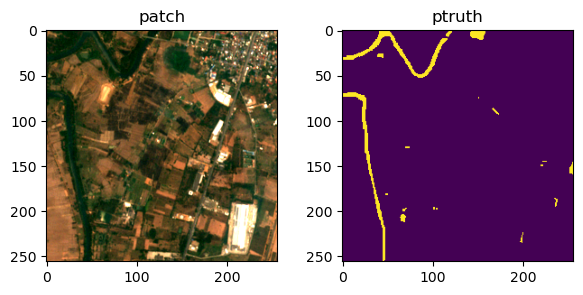

In [13]:
id = np.random.randint(0, len(patch_list_valset))
patch_ptruth = patch_list_valset[id].numpy() ##(patches,pdem,ptruth)
patch = patch_ptruth[:,:,0:6].astype(np.float32)
ptruth = patch_ptruth[:, :, -1:].astype(np.int8)  
patch_ptruth_ = [patch, ptruth]  
imgs_name = ['patch', 'ptruth']  
clip_list = [2,0]  
col_bands_list = [(2,1,0), (0,0,0)]
imsShow(img_list=patch_ptruth_, 
            img_name_list=imgs_name,
            clip_list=clip_list, 
            color_bands_list=col_bands_list,
            figsize=(7,3))
